In [106]:
# Import necessary libraries

# Basic
import numpy as np
import pandas as pd

# Graphic Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

# Datasets
from sklearn.datasets import load_iris
from sklearn.datasets import load_breast_cancer

# Models
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Utilities
from sklearn.model_selection import train_test_split
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

# Some cosmetics add-ons
import warnings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
%matplotlib inline

In [107]:
# Load dataset
SZ = pd.read_csv('SZ_Microbiome_17_8_6.csv')

In [108]:
print(f"Data Shape: {SZ.shape} \n\n")
SZ.head()

Data Shape: (50, 4) 




,6,8,17,Diagnosis
0,3,5293,1083,0
1,18468,40,2,1
2,17,1452,0,1
3,3,471,70,0
4,3,1337,0,1


In [109]:
# types of data
SZ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   6          50 non-null     int64
 1   8          50 non-null     int64
 2   17         50 non-null     int64
 3   Diagnosis  50 non-null     int64
dtypes: int64(4)
memory usage: 1.7 KB


In [110]:
pd.options.display.float_format = '{:.0f}'.format

# Synthetic descriptive statistics
print(SZ.describe())

          6    8   17  Diagnosis
count    50   50   50         50
mean    750  542  213          0
std    2697  814  321          1
min       0    0    0          0
25%       0   61    0          0
50%       4  304   67          0
75%     110  711  344          1
max   18468 5293 1521          1


# SZ vs Microbiome: Exploratory Data Analysis

In [111]:
feature_names = SZ.columns.tolist()
feature_names.remove('Diagnosis')
print(feature_names)

['6', '8', '17']


## Univariate Analysis

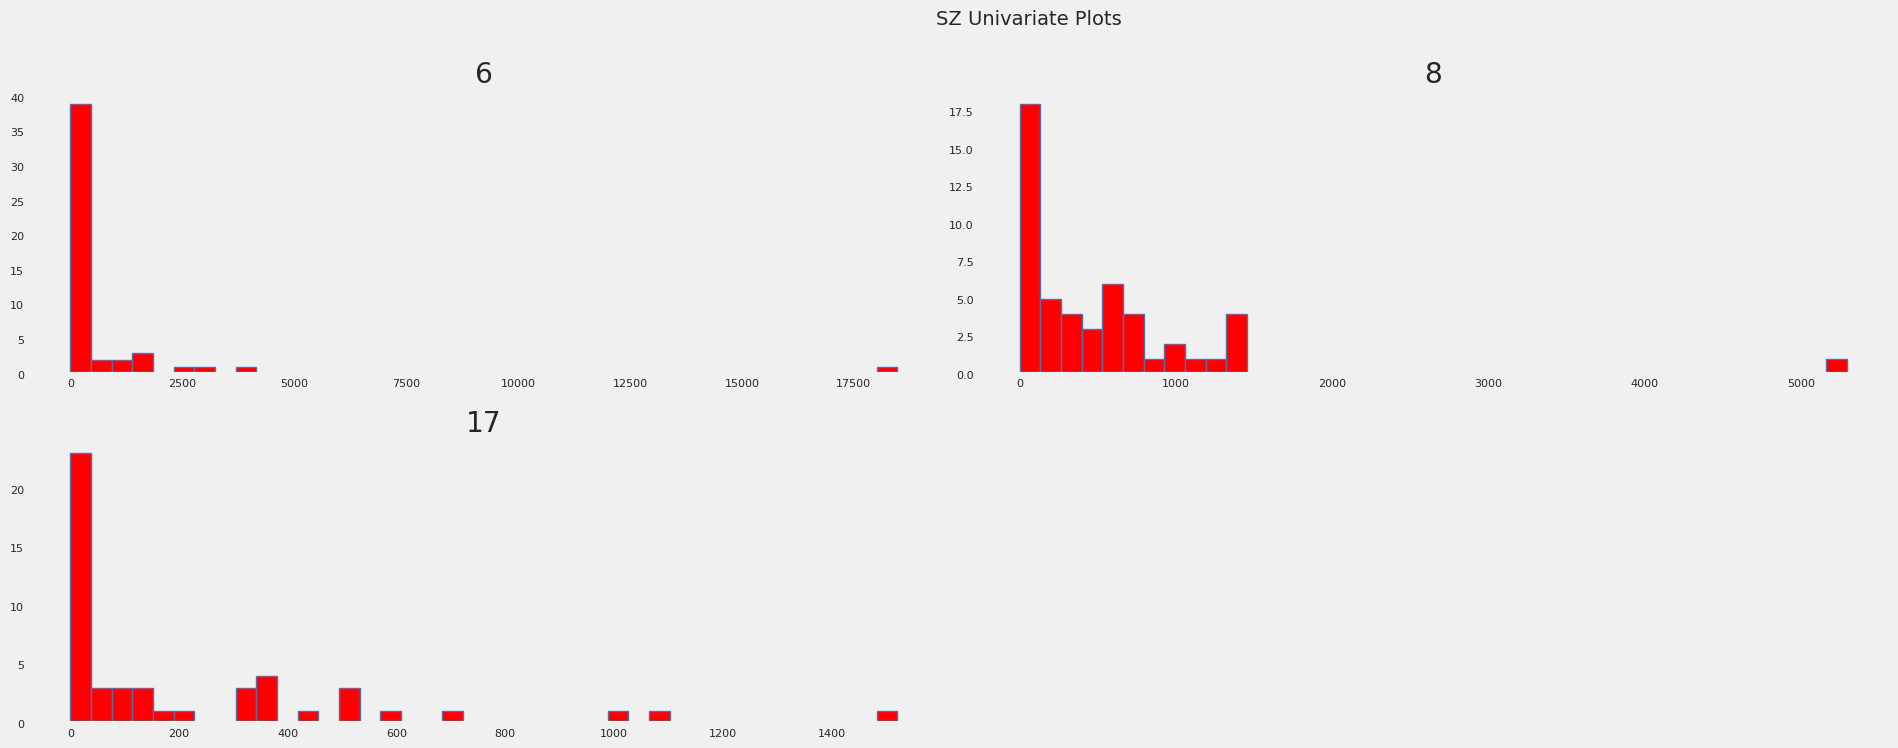

In [112]:
# Features distributions
SZ[feature_names].hist(bins=40, edgecolor='b', linewidth=1.0,
                          xlabelsize=8, ylabelsize=8, grid=False,
                          figsize=(16,6), color='red')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))
plt.suptitle('SZ Univariate Plots', x=0.65, y=1.25, fontsize=14);

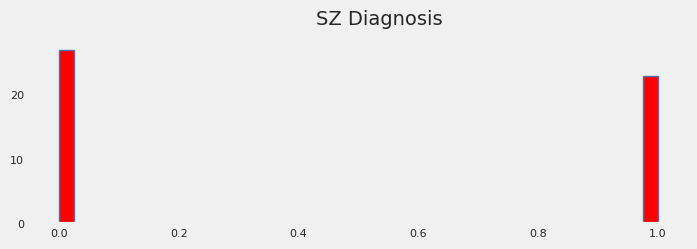

In [113]:
# Target distribution
SZ['Diagnosis'].hist(bins=40, edgecolor='b', linewidth=1.0,
              xlabelsize=8, ylabelsize=8, grid=False, figsize=(6,2), color='red')
plt.tight_layout(rect=(0, 0, 1.2, 1.2))
plt.suptitle('SZ Diagnosis', x=0.65, y=1.25, fontsize=14);

## Multivariate Analysis

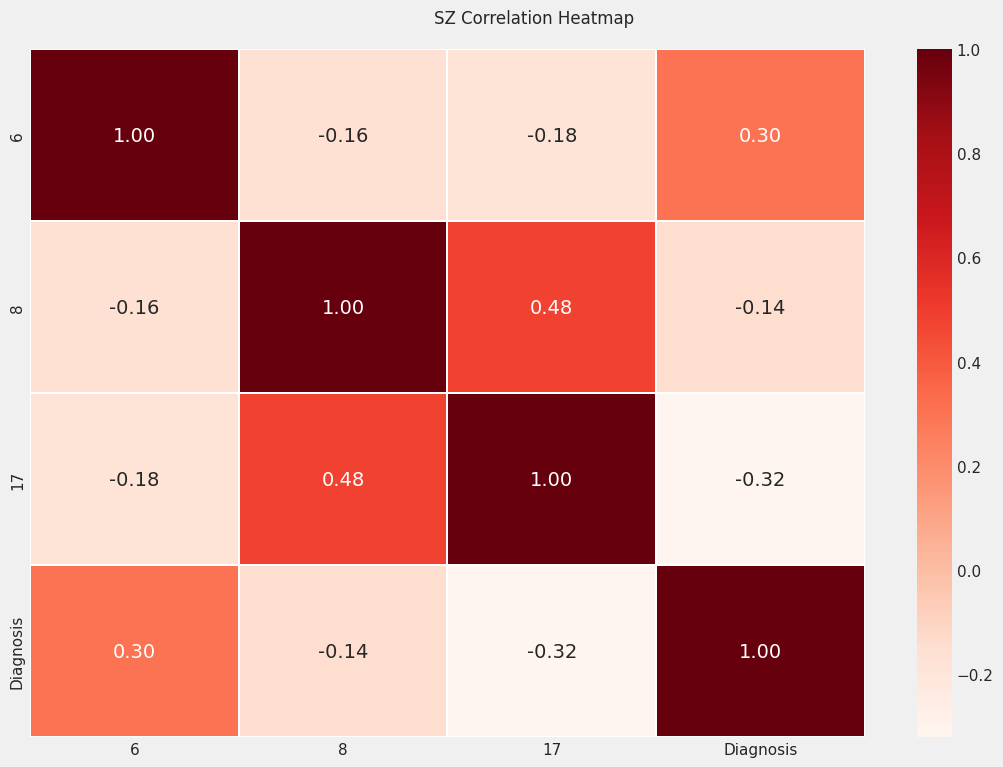

In [114]:
# Correlation matrix
f, ax = plt.subplots(figsize=(12, 8))
corr = SZ.corr()
hm = sns.heatmap(round(corr,2), annot=True, ax=ax, cmap="Reds",fmt='.2f',
            linewidths=.05)
f.subplots_adjust(top=0.93)
t= f.suptitle('SZ Correlation Heatmap', fontsize=12)

## Bivariate Features vs Target

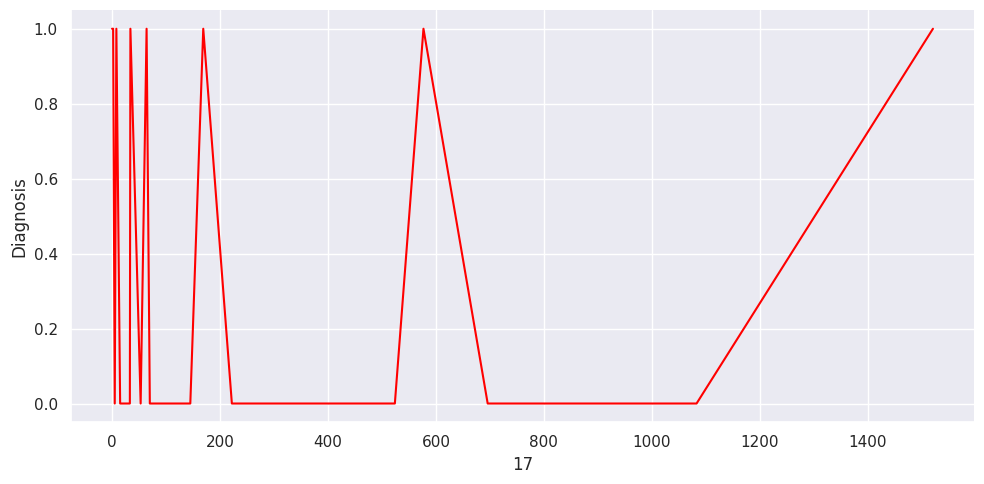

In [115]:
sns.set()
sns.relplot(data=SZ, x='17', y='Diagnosis', kind='line', height=5, aspect=2, color='red');

# SZ vs Alcohol: Exploratory Data Analysis

In [116]:
# Load dataset
SZ_Alcohol = pd.read_csv('SZ_vs_Alcohol.csv')

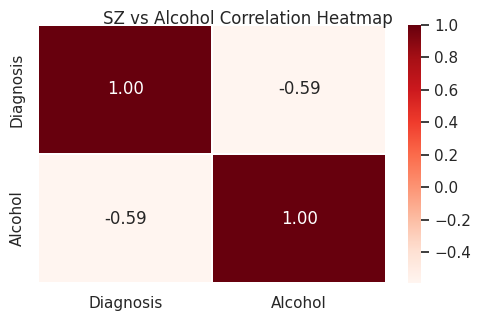

In [117]:
# Correlation matrix
f, ax = plt.subplots(figsize=(5, 3))
corr = SZ_Alcohol.corr()
hm = sns.heatmap(round(corr,2), annot=True, ax=ax, cmap="Reds",fmt='.2f',
            linewidths=.05)
f.subplots_adjust(top=0.93)
t= f.suptitle('SZ vs Alcohol Correlation Heatmap', fontsize=12)

# Decision Tree

## Evaluation

In [118]:
X_train, X_test, y_train, y_test = train_test_split(SZ[feature_names],
                                                    SZ['Diagnosis'],
                                                    test_size=0.2,
                                                    random_state=0)
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

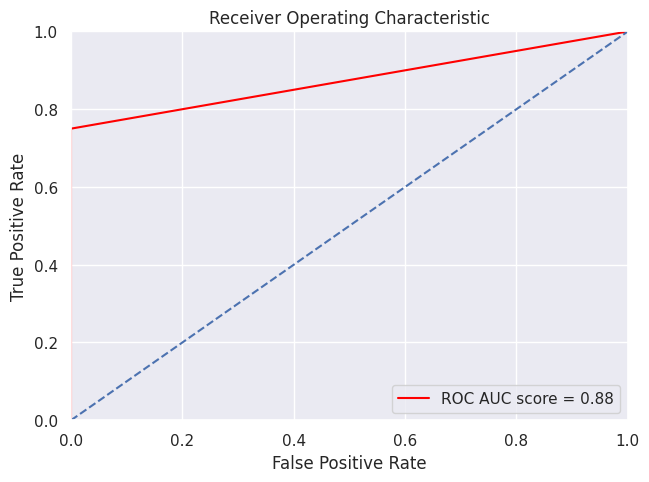

In [119]:
# calculate the FPR and TPR for all thresholds of the classification
probs = dt_model.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'red', label = 'ROC AUC score = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'b--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Decision Tree Classifier
Accuracy: 0.9
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.75      0.86         4

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10



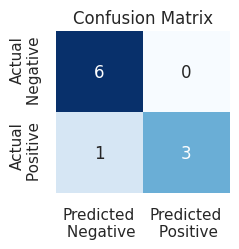

In [120]:
# Make predictions with the trained model
y_pred = dt_model.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
conf_matrix = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(2, 2))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted\n Negative', 'Predicted\n Positive'],
            yticklabels=['Actual\n Negative', 'Actual\n Positive'])
plt.title('Confusion Matrix')
plt.show()

## Interpretation

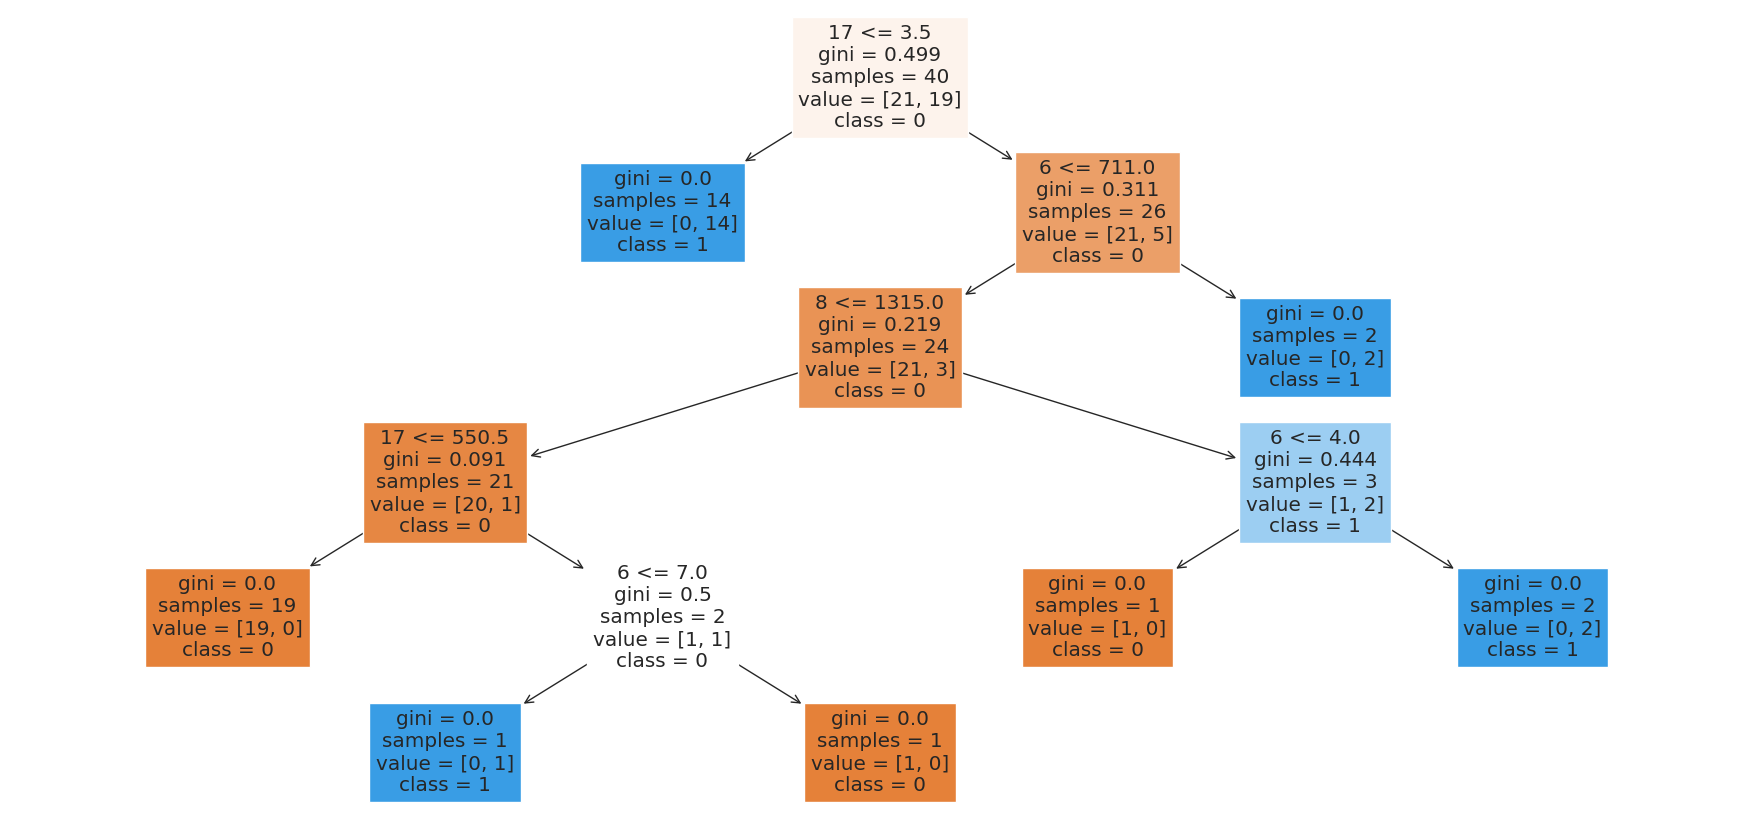

In [121]:
# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=feature_names, class_names=['0','1'], filled=True)
plt.show()

Text(0, 0.5, 'Feature')

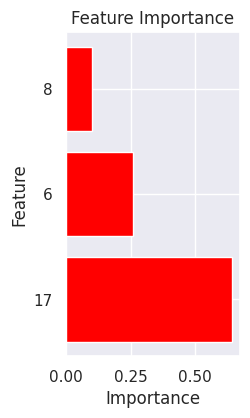

In [122]:
# ploting feature importance
importance = dt_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize = (2, 4))
plt.title("Feature Importance", fontsize=14)

plt.barh(importance_df['Feature'], importance_df['Importance'], color='red')
plt.title("Feature Importance")
plt.xlabel('Importance')
plt.ylabel('Feature')

## Cross-Validated Scores

In [123]:
X, _, y, _ = train_test_split(SZ[feature_names], SZ['Diagnosis'], random_state=1)

X_folds = np.array_split(X, 5)
y_folds = np.array_split(y, 5)
scores_dt = list()
for k in range(5):
    # We use 'list' to copy, in order to 'pop' later on
    X_train_XV = list(X_folds)
    X_test_XV = X_train_XV.pop(k)
    X_train_XV = np.concatenate(X_train_XV)
    y_train_XV = list(y_folds)
    y_test_XV = y_train_XV.pop(k)
    y_train_XV = np.concatenate(y_train_XV)
    scores_dt.append(dt_model.fit(X_train_XV, y_train_XV).score(X_test_XV, y_test_XV))
print(scores_dt)

[1.0, 0.875, 1.0, 0.7142857142857143, 0.8571428571428571]


## Global Model-Agnostic Methods

### SHAP

In [124]:
!pip install --upgrade rulefit shap

(40, 3, 2)
(10, 3, 2)
SHAP values for training data shape: (3, 2)
SHAP values for test data shape: (3, 2)
SHAP summary plot for Class 0 (training data)


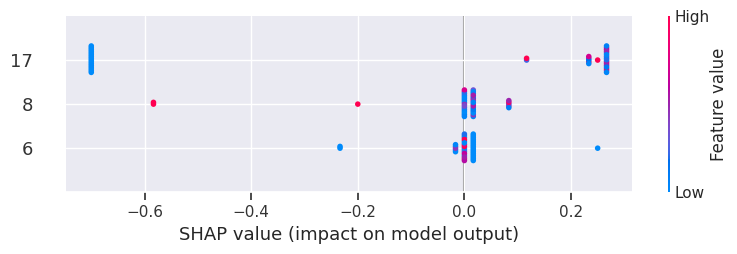

SHAP summary plot for Class 0 (test data)


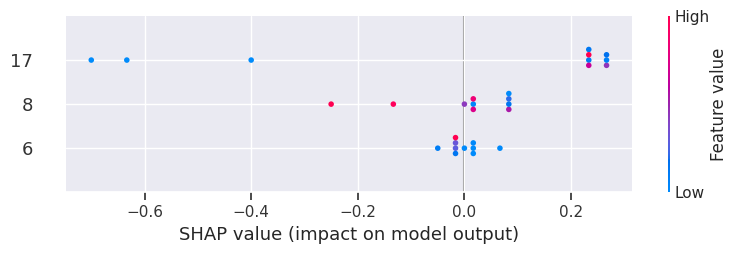

SHAP bar plot for Class 0 (test data)


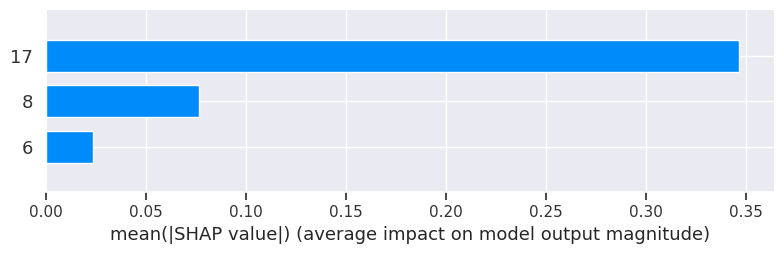

SHAP summary plot for Class 1 (training data)


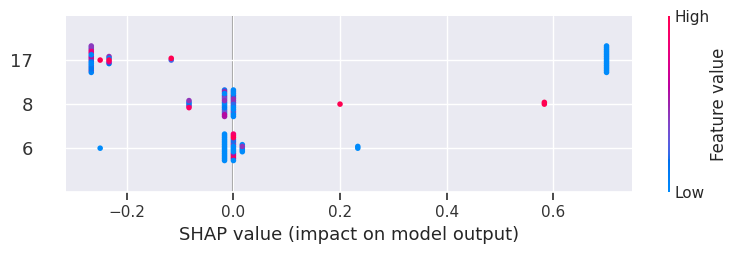

SHAP summary plot for Class 1 (test data)


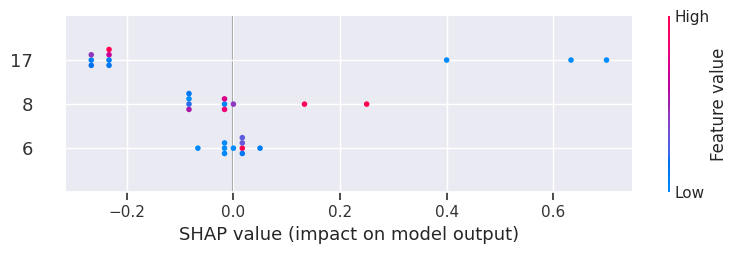

SHAP bar plot for Class 1 (test data)


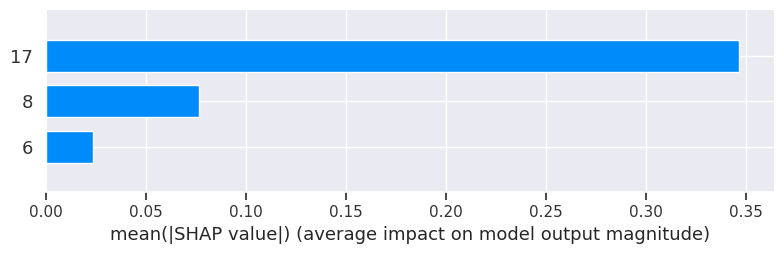

SHAP dependence plot for feature '6' (training data, Class 1)


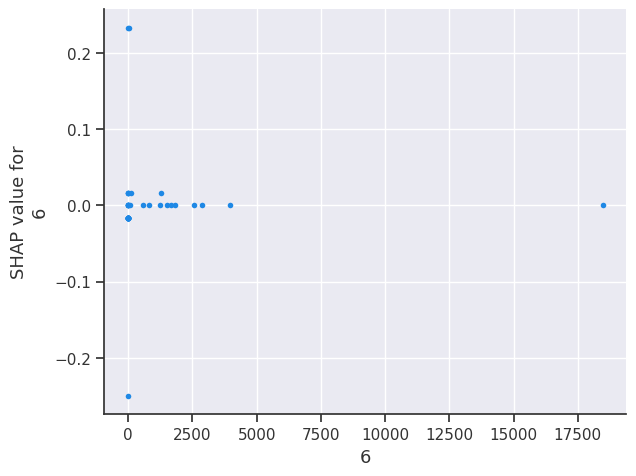

SHAP dependence plot for feature '6' (test data, Class 1)


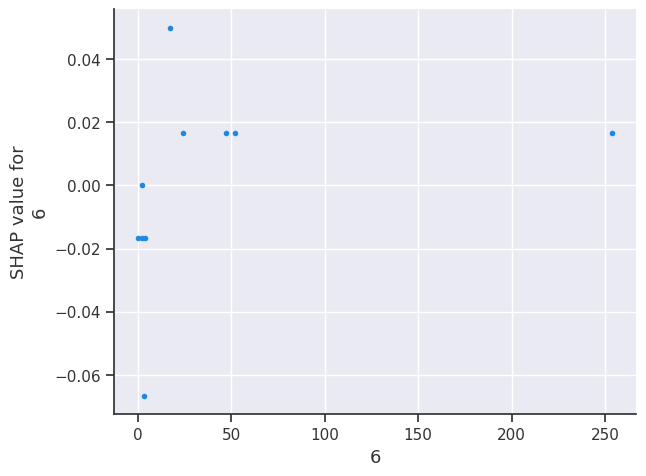

SHAP dependence plot for feature '8' (training data, Class 1)


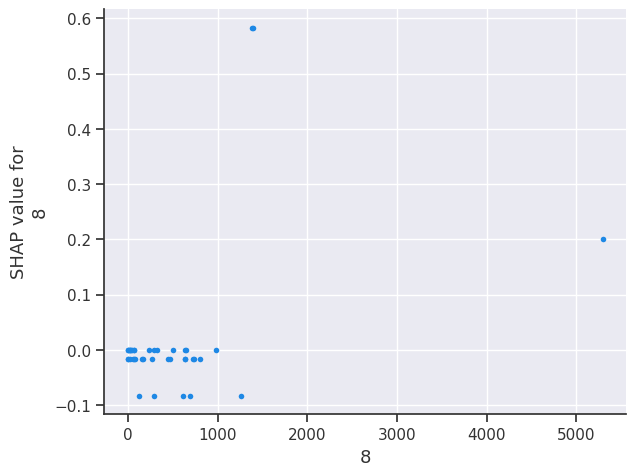

SHAP dependence plot for feature '8' (test data, Class 1)


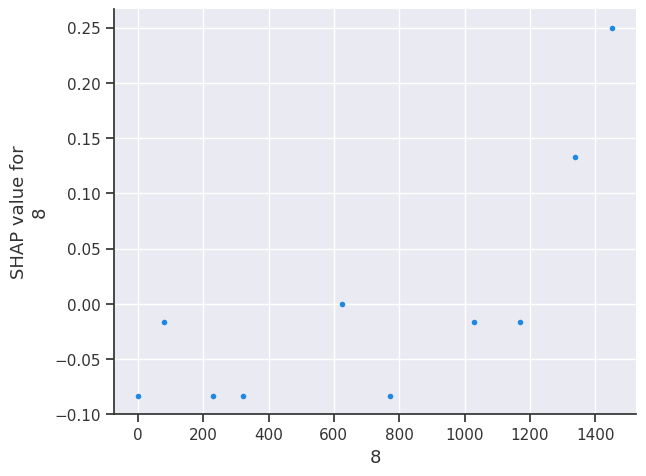

SHAP dependence plot for feature '17' (training data, Class 1)


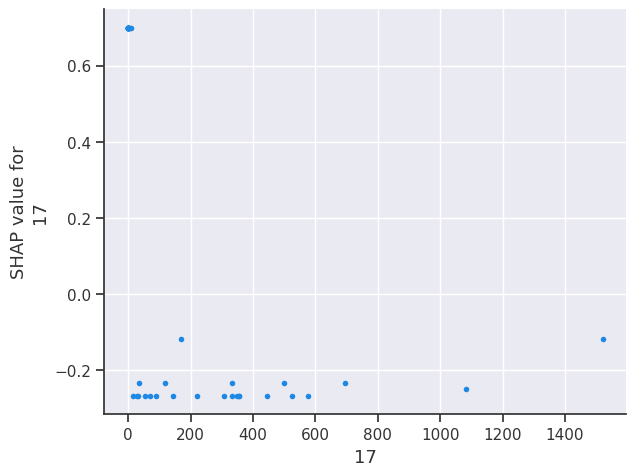

SHAP dependence plot for feature '17' (test data, Class 1)


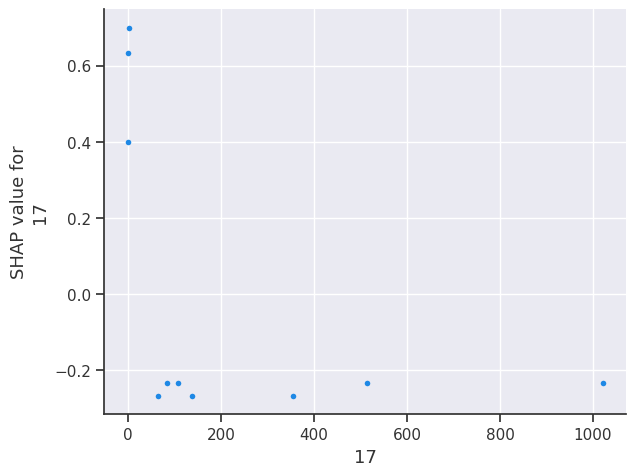

In [125]:
import shap

# Fit the SHAP explainer
dt_explainer = shap.TreeExplainer(dt_model, X_test)
shap_dt_values_train = dt_explainer.shap_values(X_train)
print(shap_dt_values_train.shape)
shap_dt_values_test = dt_explainer.shap_values(X_test)
print(shap_dt_values_test.shape)

# Check the shapes of SHAP values
print("SHAP values for training data shape:", shap_dt_values_train[0].shape)
print("SHAP values for test data shape:", shap_dt_values_test[0].shape)

# Define class names
class_names = ['Class 0', 'Class 1']  # Replace with your actual class names if different

# Plot SHAP values for each class separately
for class_idx, class_name in enumerate(class_names):
    print(f"SHAP summary plot for {class_name} (training data)")
    shap.summary_plot(shap_dt_values_train[:, :, class_idx], X_train, plot_type="dot", title=f"SHAP summary plot for {class_name} (training data)")
    plt.show()

    print(f"SHAP summary plot for {class_name} (test data)")
    shap.summary_plot(shap_dt_values_test[:, :, class_idx], X_test, plot_type="dot", title=f"SHAP summary plot for {class_name} (test data)")
    plt.show()

    print(f"SHAP bar plot for {class_name} (test data)")
    shap.summary_plot(shap_dt_values_test[:, :, class_idx], X_test, plot_type="bar", title=f"SHAP bar plot for {class_name} (test data)")
    plt.show()


selected_features = X.columns[:15]
for feature in selected_features:
    print(f"SHAP dependence plot for feature '{feature}' (training data, {class_name})")
    shap.dependence_plot(feature, shap_dt_values_train[:, :, class_idx], X_train, interaction_index=None)
    plt.show()

    print(f"SHAP dependence plot for feature '{feature}' (test data, {class_name})")
    shap.dependence_plot(feature, shap_dt_values_test[:, :, class_idx], X_test, interaction_index=None)
    plt.show()

X_train shape: (40, 3)
X_test shape: (10, 3)
SHAP values for training data shape: (40, 3, 2)
SHAP values for test data shape: (10, 3, 2)
SHAP summary plot for Class 0 (training data)


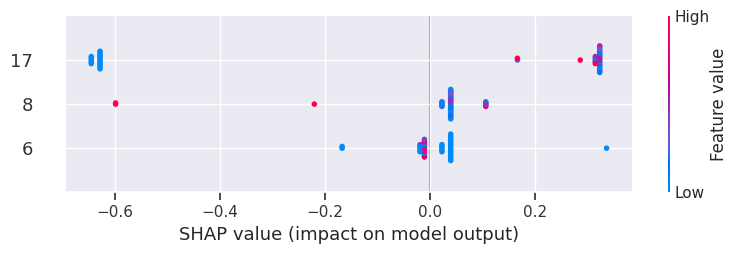

SHAP summary plot for Class 0 (test data)


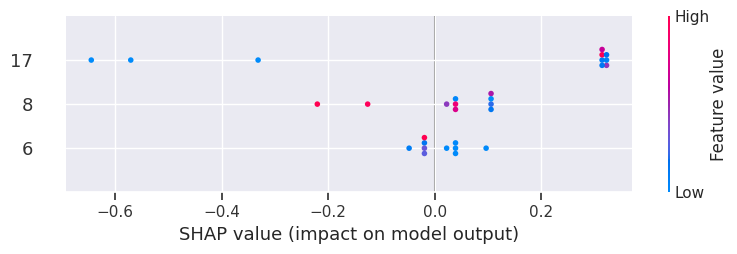

SHAP bar plot for Class 0 (test data)


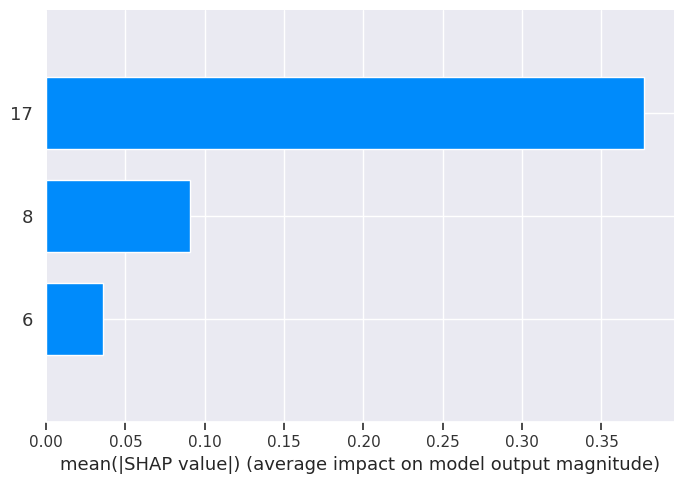

SHAP summary plot for Class 1 (training data)


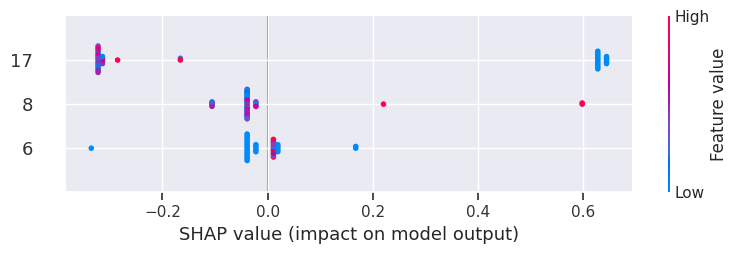

SHAP summary plot for Class 1 (test data)


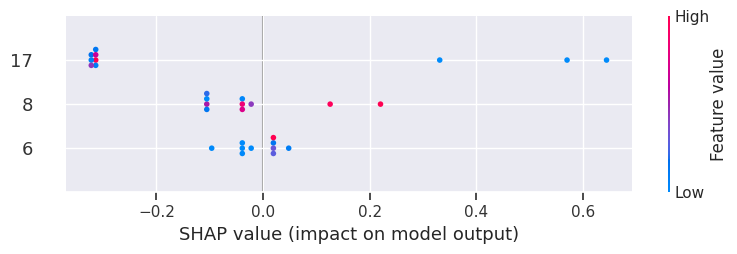

SHAP bar plot for Class 1 (test data)


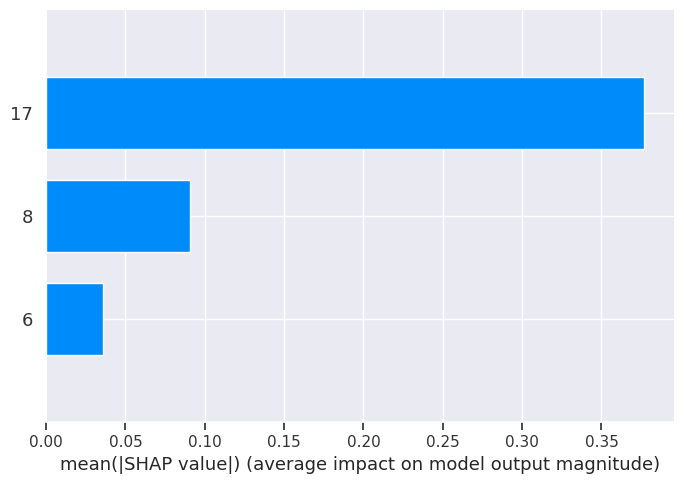

In [126]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np

# Fit the SHAP explainer
dt_explainer = shap.TreeExplainer(dt_model)
shap_dt_values_train = dt_explainer.shap_values(X_train)
shap_dt_values_test = dt_explainer.shap_values(X_test)

# Verify shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Ensure shap values are lists
if isinstance(shap_dt_values_train, list):
    print("SHAP values for training data shape:", shap_dt_values_train[0].shape)
else:
    print("SHAP values for training data shape:", shap_dt_values_train.shape)

if isinstance(shap_dt_values_test, list):
    print("SHAP values for test data shape:", shap_dt_values_test[0].shape)
else:
    print("SHAP values for test data shape:", shap_dt_values_test.shape)

# Define class names
class_names = ['Class 0', 'Class 1']  # Replace with your actual class names if different

# Plot SHAP values for each class separately
for class_idx, class_name in enumerate(class_names):
    print(f"SHAP summary plot for {class_name} (training data)")
    shap.summary_plot(shap_dt_values_train[:, :, class_idx],
                      X_train,
                      plot_type="dot",
                      title=f"SHAP summary plot for {class_name} (training data)")
    plt.show()
    plt.show()

    print(f"SHAP summary plot for {class_name} (test data)")
    shap.summary_plot(shap_dt_values_test[:, :, class_idx],
                      X_test,
                      plot_type="dot",
                      title=f"SHAP summary plot for {class_name} (test data)")
    plt.show()

    print(f"SHAP bar plot for {class_name} (test data)")
    shap.summary_plot(shap_dt_values_test[:, :, class_idx],
                      X_test,
                      plot_type="bar",
                      title=f"SHAP bar plot for {class_name} (test data)",
                      plot_size=(7, 5))
    plt.show()

### PDP

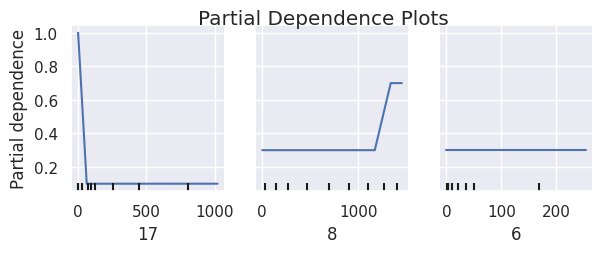

In [127]:
# Define the features for which you want to plot PDPs
important_feature_indices  = [2, 1, 0]  # Replace with indices of features you want to explore

# Create PDP plots
fig, ax = plt.subplots(figsize=(6, 2))
display = PartialDependenceDisplay.from_estimator(
    dt_model, X_test, features=important_feature_indices, ax=ax
)
plt.suptitle('Partial Dependence Plots')
plt.subplots_adjust(top=0.9)  # Adjust title position
plt.show()

### ICE

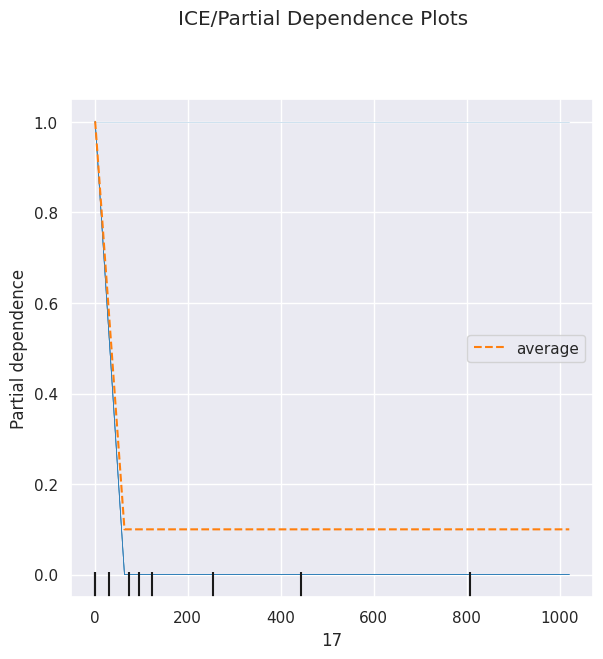

In [128]:
important_feature_indices  = [2]  # Replace with indices of features you want to explore

# Create ICE/PDP plots
fig, ax = plt.subplots(figsize=(6, 6))
display = PartialDependenceDisplay.from_estimator(
    dt_model, X_test, features=important_feature_indices, kind='both', ax=ax
)
plt.suptitle('ICE/Partial Dependence Plots', y=1.05)
plt.subplots_adjust(top=0.9)  # Adjust title position
plt.show()

### ALE

In [129]:
!pip install git+https://github.com/MaximeJumelle/ALEPython.git@dev#egg=alepython

  Cloning https://github.com/MaximeJumelle/ALEPython.git (to revision dev) to /tmp/pip-install-6ykv9ggn/alepython_f6768cff80ac4c8a915d67f8e0bff345
  Running command git clone --filter=blob:none --quiet https://github.com/MaximeJumelle/ALEPython.git /tmp/pip-install-6ykv9ggn/alepython_f6768cff80ac4c8a915d67f8e0bff345
  Resolved https://github.com/MaximeJumelle/ALEPython.git to commit 286350ab674980a32270db2a0b5ccca1380312a7
  Preparing metadata (setup.py) ... done


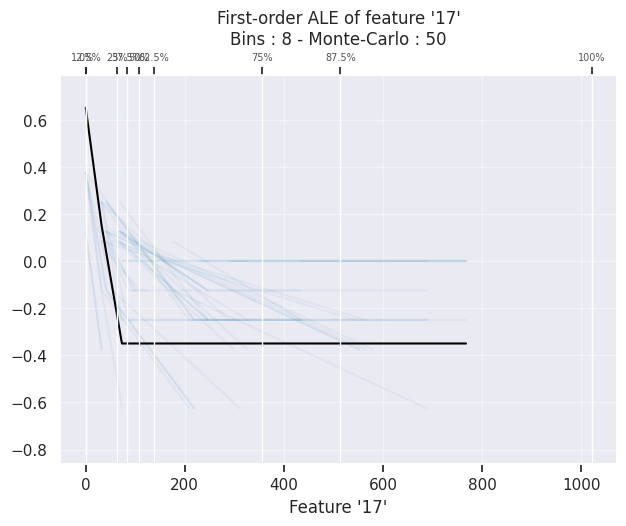

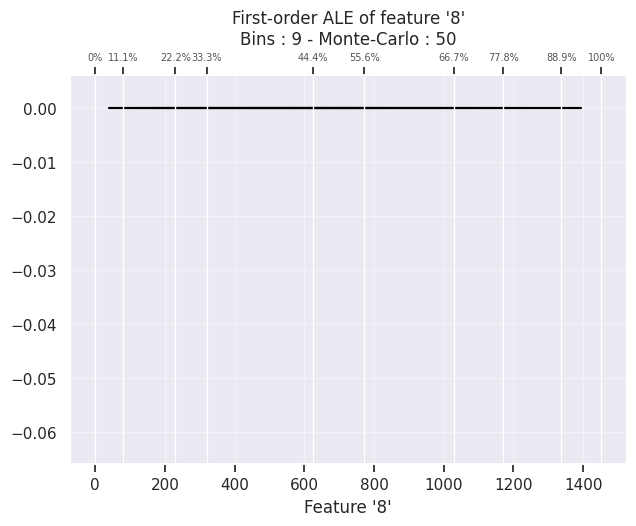

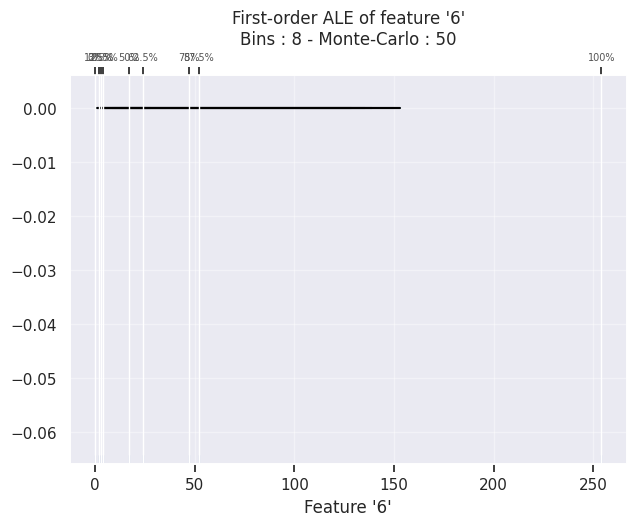

In [130]:
from alepython import ale_plot

for name in ['17', '8', '6']:

  ale_plot(

  dt_model, X_test, [name], bins=10,\

  monte_carlo=True, monte_carlo_rep=50, monte_carlo_ratio=0.4

  )

  plt.show()

## Local Model-Agnostic Methods

### LIME

In [131]:
!pip install --upgrade shap lime

In [132]:
import lime
import lime.lime_tabular
from lime.lime_text import LimeTextExplainer

print(X_test.index)

# Determine which indices have correct predictions
results = {'True Positive': [], 'True Negative': [], 'False Positive': [], 'False Negative': []}

for i in range(len(X_test)):
    idx = X_test.index[i]
    true_label = y_test.iloc[i]
    pred_label = y_pred[i]

    if true_label == 1 and pred_label == 1:
        results['True Positive'].append(idx)
    elif true_label == 0 and pred_label == 0:
        results['True Negative'].append(idx)
    elif true_label == 0 and pred_label == 1:
        results['False Positive'].append(idx)
    elif true_label == 1 and pred_label == 0:
        results['False Negative'].append(idx)

print("True Positives:", results['True Positive'])
print("True Negatives:", results['True Negative'])
print("False Positives:", results['False Positive'])
print("False Negatives:", results['False Negative'])

explainer = lime.lime_tabular.LimeTabularExplainer(X_train.values,
                                                   feature_names=X_train.columns,
                                                   class_names=['0', '1'])

explainer.explain_instance(X_test[X_test.index==41].values[0],\
                                    dt_model.predict_proba,\
                                    num_features=10).\
                                show_in_notebook(predict_proba=True)

explainer.explain_instance(X_test[X_test.index==28].values[0],\
                                    dt_model.predict_proba,\
                                    num_features=10).\
                                show_in_notebook(predict_proba=True)

explainer.explain_instance(X_test[X_test.index==38].values[0],\
                                    dt_model.predict_proba,\
                                    num_features=10).\
                                show_in_notebook(predict_proba=True)

Output hidden; open in https://colab.research.google.com to view.

### Anchors

In [133]:
!pip install --upgrade machine_learning_datasets
!pip install --upgrade catboost witwidget
!pip install alibi[tensorflow]

In [134]:
from alibi.utils.mapping import ohe_to_ord, ord_to_ohe
from alibi.explainers import AnchorTabular
from alibi.explainers import CEM
from sklearn.preprocessing import KBinsDiscretizer

In [135]:
if isinstance(X_train, pd.DataFrame):
    X_train = X_train.values

In [136]:
explainer = AnchorTabular(predictor=dt_model.predict, feature_names=feature_names)
explainer.fit(X_train)

AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': None, 'disc_perc': (25, 50, 75)},
  'version': '0.9.6'}
)

In [137]:
instance = X_test.iloc[1].values.reshape(1, -1)
print(f"Instance to explain: {instance}")
explanation = explainer.explain(instance, threshold=0.95)

Instance to explain: [[ 24 230 108]]


In [138]:
print('Anchor: %s' % (' AND '.join(explanation.data['anchor'])))
print('Precision: %.2f' % explanation.data['precision'])
print('Coverage: %.2f' % explanation.data['coverage'])

Anchor: 17 > 43.50
Precision: 0.95
Coverage: 0.50


### Counterfactuals

In [139]:
import tensorflow as tf

tf.get_logger().setLevel(40) # suppress deprecation
tf.compat.v1.disable_v2_behavior() # disable TF2 behaviour as alibi code still relies on TF1 constructs

from tensorflow import keras
from tensorflow.keras import layers

from alibi.explainers import CounterFactualProto

import witwidget
from witwidget.notebook.visualization import WitWidget, WitConfigBuilder

In [140]:
feature_range = (X_train.min(axis=0).reshape(1,3).astype(np.float32),\
                 X_train.max(axis=0).reshape(1,3).astype(np.float32))
print(feature_range)

(array([[0., 0., 0.]], dtype=float32), array([[18468.,  5293.,  1521.]], dtype=float32))


In [141]:
idx1 = 38

X_test_eval = np.expand_dims(X_test.values[X_test.\
                                           index.get_loc(idx1)], axis=0)
print(X_test_eval)

predict_nn_fn = lambda x: np.concatenate(((1 - dt_model.predict(x))[:, np.newaxis],\
                                          dt_model.predict(x)[:, np.newaxis]), axis=1)

cf_nn_explainer = CounterFactualProto(predict_nn_fn,
                                    X_test_eval.shape,
                                    max_iterations=1000,
                                    feature_range=feature_range,
                                    beta=.05, theta=30,
                                    use_kdtree=True
                                )
cf_nn_explainer.fit(X_test.values, d_type='abdm-mvdm')

[[ 4 81 64]]


CounterfactualProto(meta={
  'name': 'CounterfactualProto',
  'type': ['blackbox', 'tensorflow', 'keras'],
  'explanations': ['local'],
  'params': {
              'kappa': 0.0,
              'beta': 0.05,
              'gamma': 0.0,
              'theta': 30,
              'cat_vars': None,
              'ohe': False,
              'use_kdtree': True,
              'learning_rate_init': 0.01,
              'max_iterations': 1000,
              'c_init': 10.0,
              'c_steps': 10,
              'eps': (0.001, 0.001),
              'clip': (-1000.0, 1000.0),
              'update_num_grad': 1,
              'write_dir': None,
              'feature_range': (array([[0., 0., 0.]], dtype=float32), array([[18468.,  5293.,  1521.]], dtype=float32)),
              'shape': (1, 3),
              'is_model': False,
              'is_ae': False,
              'is_enc': False,
              'enc_or_kdtree': True,
              'is_cat': False,
              'trustscore_kwargs': None,
    

In [142]:
import machine_learning_datasets as mldatasets

class_names = ['0', '1']
cat_vars_ohe = {}
category_map = {}

cf_nn_explanation = cf_nn_explainer.explain(X_test_eval)
mldatasets.describe_cf_instance(X_test_eval, cf_nn_explanation, class_names,\
                  cat_vars_ohe=cat_vars_ohe, category_map=category_map, feature_names=feature_names)

Instance Outcomes and Probabilities
------------------------------------------------
original:  0
     [1 0]
counterfactual:  1
     [0 1]

Categorical Feature Counterfactual Perturbations
------------------------------------------------

Numerical Feature Counterfactual Perturbations
------------------------------------------------
	 6:  4.00  -->  2.10
	 8:  81.00  -->  135.69
	17:  64.00  -->  9.31


In [143]:
test_df = SZ.loc[y_test.index]
test_np = test_df.values
cols_l = test_df.columns
delcol_idx = [cols_l.get_loc("17"),\
              cols_l.get_loc("8"), \
              cols_l.get_loc("6")]

In [144]:
def custom_predict_with_shap(examples_np):
    #For shap values we only need same features
    #that were used for training
    inputs_np = np.delete(np.array(examples_np),\
                          delcol_idx, axis=1)

    #With test data generate SHAP values which converted
    #to a list of dictionaries format
    keepcols_l = [c for i, c in enumerate(cols_l)\
                  if i not in delcol_idx]
    shap_output = dt_explainer.shap_values(inputs_np)
    attributions = []
    for shap in shap_output:
        attrs = {}
        for i, col in enumerate(keepcols_l):
            attrs[col] = shap[i]
        attributions.append(attrs)

    #Prediction function must output
    #predictions/attributions in dictionary
    output = {'predictions': preds,\
              'attributions': attributions}
    return output

In [145]:
print(y_test.index.get_loc(38))

6


In [146]:
wit_config_builder = WitConfigBuilder(\
                    test_np.tolist(), feature_names=cols_l.tolist()
                ).set_custom_predict_fn(custom_predict_with_shap).\
                set_target_feature("diagnosis").set_label_vocab(class_names)
WitWidget(wit_config_builder, height=800)

Output hidden; open in https://colab.research.google.com to view.

# Random Forest Classifier

## Evaluation

In [147]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)


RandomForestClassifier()

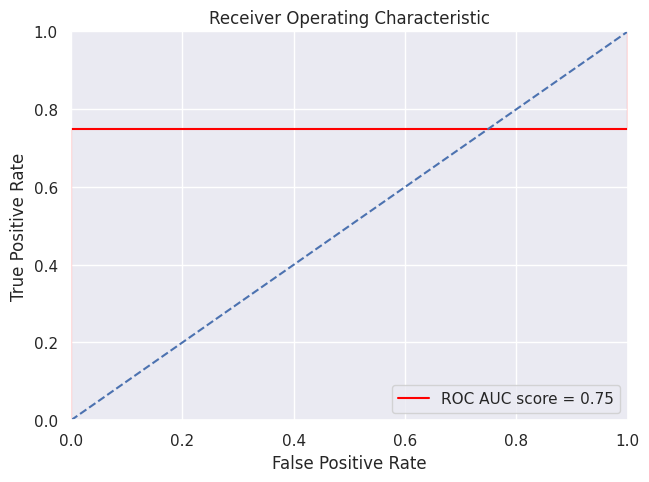

In [148]:
# calculate the FPR and TPR for all thresholds of the classification
probs = rf_model.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'red', label = 'ROC AUC score = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'b--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Random Forest Classifier
Accuracy: 0.9
Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.92         6
           1       1.00      0.75      0.86         4

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10



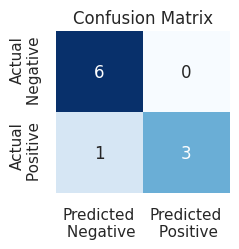

In [149]:
# Make predictions with the trained model
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
conf_matrix = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(2, 2))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted\n Negative', 'Predicted\n Positive'],
            yticklabels=['Actual\n Negative', 'Actual\n Positive'])
plt.title('Confusion Matrix')
plt.show()

## Interpretation

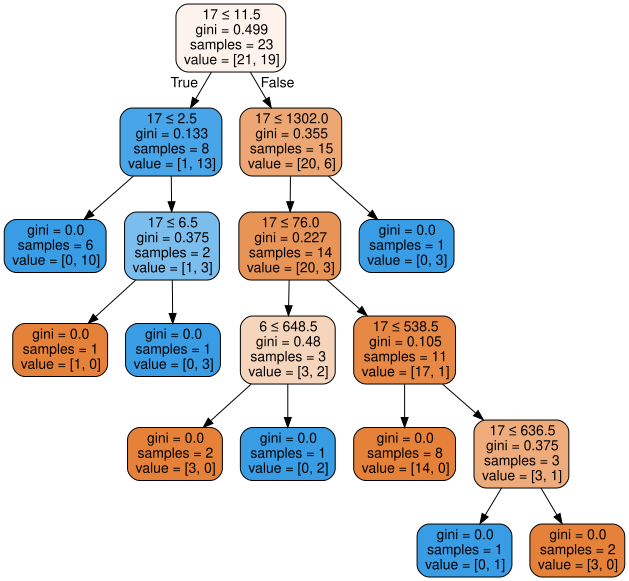

In [150]:
# Plot one of the trees in the forest
estimator = rf_model.estimators_[2]

# Export the tree to DOT format
dot_data = export_graphviz(estimator, out_file=None,
                           feature_names=feature_names,
                           filled=True, rounded=True,
                           special_characters=True)

# Use graphviz to render the tree
graph = graphviz.Source(dot_data)
graph.render("random_forest_tree")

# Display the tree inline
graph

Text(0, 0.5, 'Feature')

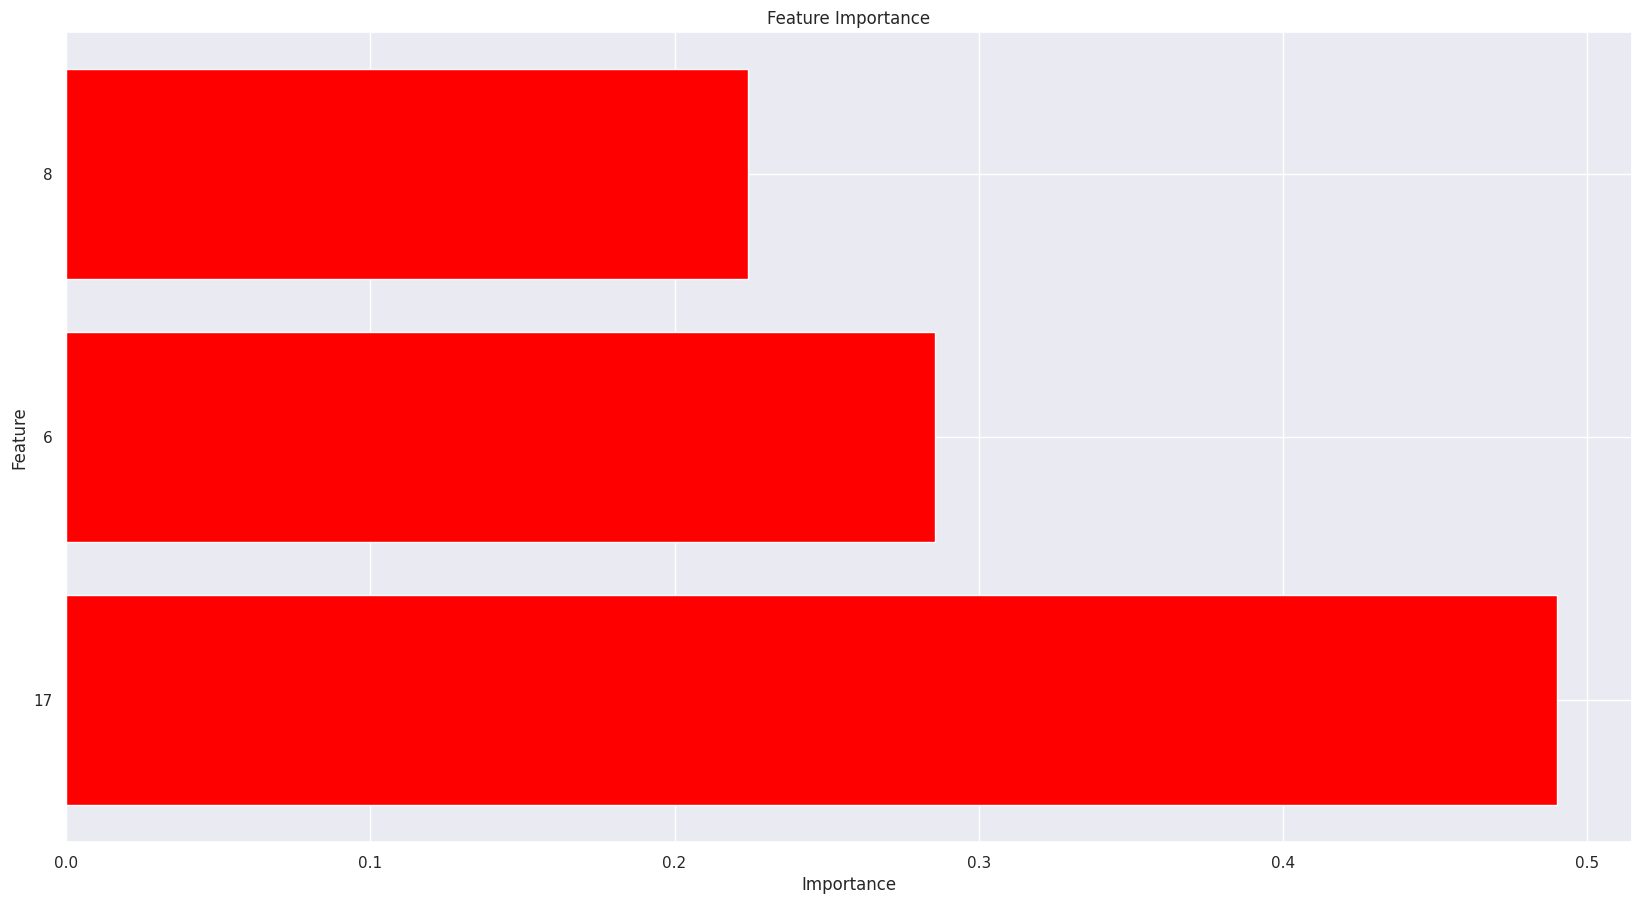

In [151]:
# ploting feature importance
importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize = (18, 10))
plt.title("Feature Importance", fontsize=14)

plt.barh(importance_df['Feature'], importance_df['Importance'], color='red')
plt.title("Feature Importance")
plt.xlabel('Importance')
plt.ylabel('Feature')

## Cross-Validated Scores

In [152]:
scores_rf = list()
for k in range(5):
    # We use 'list' to copy, in order to 'pop' later on
    X_train_XV = list(X_folds)
    X_test_XV = X_train_XV.pop(k)
    X_train_XV = np.concatenate(X_train_XV)
    y_train_XV = list(y_folds)
    y_test_XV = y_train_XV.pop(k)
    y_train_XV = np.concatenate(y_train_XV)
    scores_rf.append(rf_model.fit(X_train_XV, y_train_XV).score(X_test_XV, y_test_XV))
print(scores_rf)

[1.0, 1.0, 0.8571428571428571, 0.8571428571428571, 0.8571428571428571]


## Global Model-Agnostic Methods

### PDP

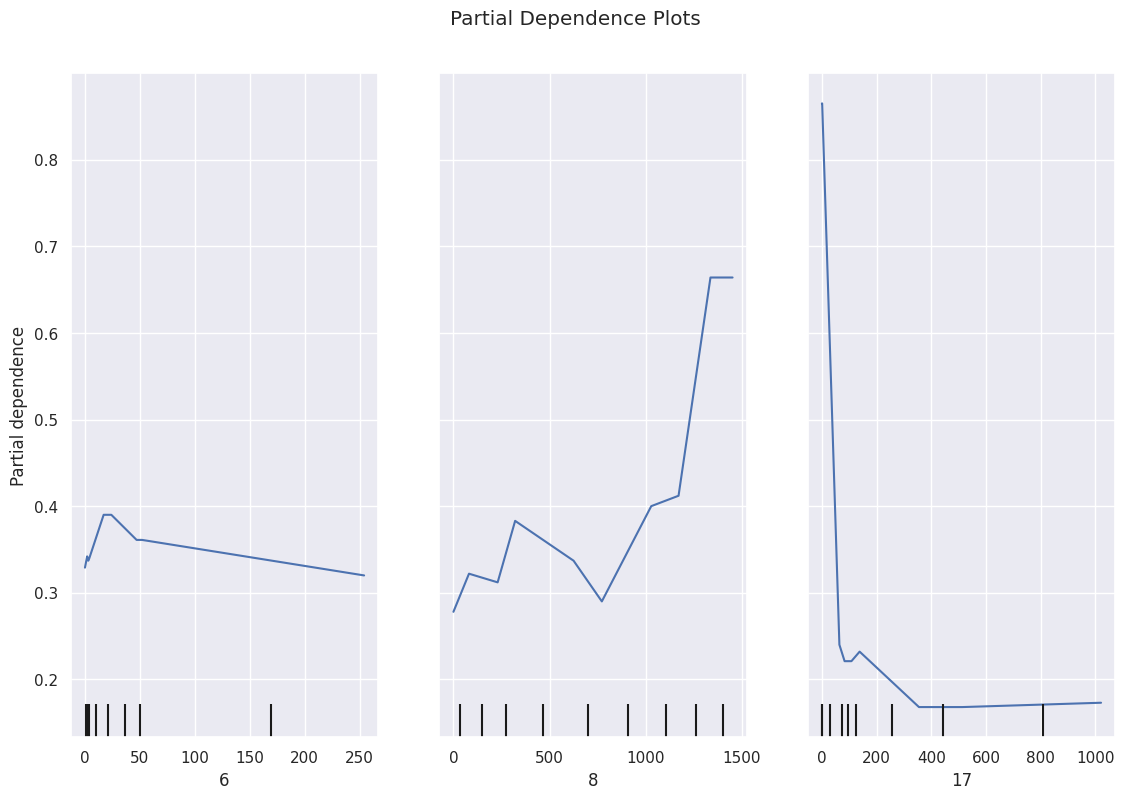

In [153]:
# Define the features for which you want to plot PDPs
important_feature_indices  = [0, 1, 2 ]  # Replace with indices of features you want to explore

# Create PDP plots
fig, ax = plt.subplots(figsize=(12, 8))
display = PartialDependenceDisplay.from_estimator(
    rf_model, X_test, features=important_feature_indices, ax=ax
)
plt.suptitle('Partial Dependence Plots')
plt.subplots_adjust(top=0.9)  # Adjust title position
plt.show()

# Logistic Regression

## Evaluation

In [154]:
LR = LogisticRegression()
LR.fit(X_train, y_train)

LogisticRegression()

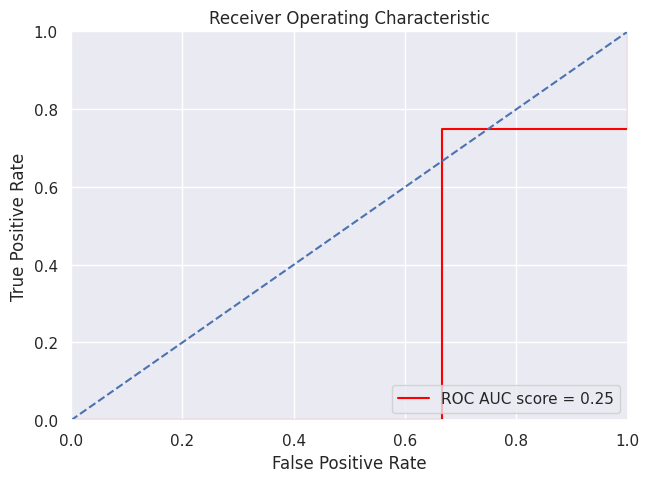

In [155]:
# calculate the FPR and TPR for all thresholds of the classification
probs = LR.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'red', label = 'ROC AUC score = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'b--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [156]:
# Make predictions with the trained model
y_pred = LR.predict(X_test)

Logistic Regression
Accuracy: 0.5
Confusion Matrix:
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.00      0.00      0.00         4

    accuracy                           0.50        10
   macro avg       0.28      0.42      0.33        10
weighted avg       0.33      0.50      0.40        10



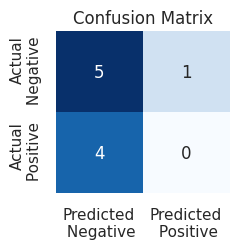

In [157]:
# Evaluate the model
print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(2, 2))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted\n Negative', 'Predicted\n Positive'],
            yticklabels=['Actual\n Negative', 'Actual\n Positive'])
plt.title('Confusion Matrix')
plt.show()

## Interpretation

In [158]:
# Print the coefficients

coefficients = LR.coef_[0]
intercept = LR.intercept_[0]

print("Intercept:", intercept)

width = 15
print(f"{'Feature':<{width}} {'Coefficient':>{width}}")

for feature, coefficient in zip(feature_names, coefficients):
    print(f"{feature:<{width}} {coefficient:>{width}.6f}")

Intercept: -0.9546423978036359
Feature             Coefficient
6                      0.005983
8                     -0.000135
17                     0.000117


Text(0, 0.5, 'Feature')

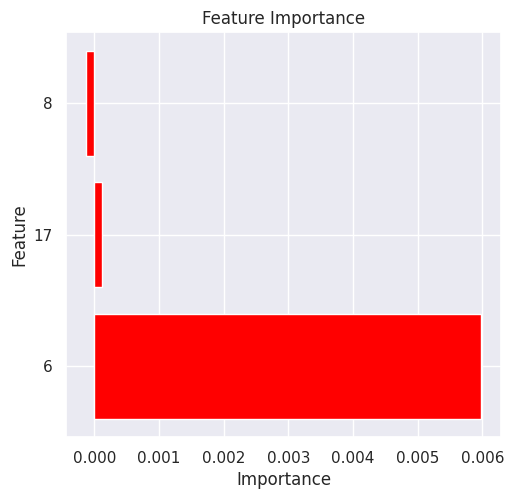

In [159]:
# ploting feature importance
importance = LR.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)


plt.figure(figsize = (5, 5))
plt.title("Feature Importance", fontsize=14)

plt.barh(importance_df['Feature'], importance_df['Importance'], color='red')
plt.title("Feature Importance")
plt.xlabel('Importance')
plt.ylabel('Feature')

# PLR (Penalized Logistic Regression)

In [160]:
PLR = LogisticRegression(penalty='l2', C=1.0, multi_class='ovr', max_iter=1000)

PLR.fit(X_train, y_train)
y_pred = PLR.predict(X_test)

## Evaluation

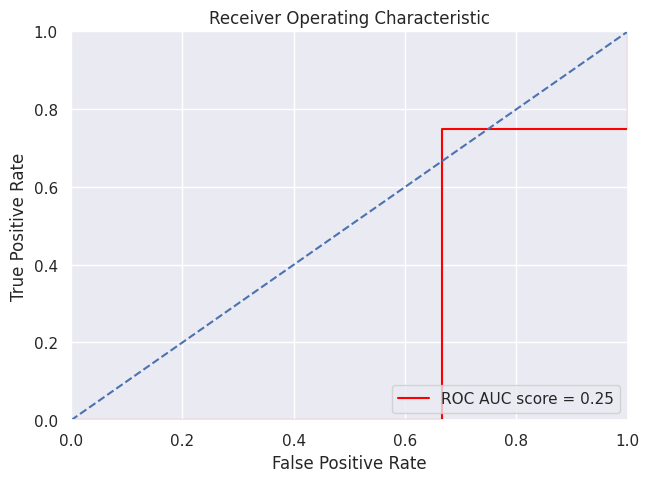

In [161]:
# calculate the FPR and TPR for all thresholds of the classification
probs = PLR.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'red', label = 'ROC AUC score = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'b--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Penalized Logistic Regression
Accuracy: 0.5
Confusion Matrix:
Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.00      0.00      0.00         4

    accuracy                           0.50        10
   macro avg       0.28      0.42      0.33        10
weighted avg       0.33      0.50      0.40        10



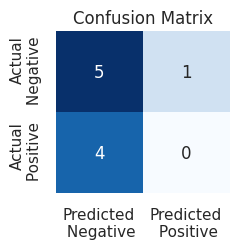

In [162]:
# Evaluate the model
print("Penalized Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("Confusion Matrix:")
conf_matrix = confusion_matrix(y_test, y_pred)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the confusion matrix
plt.figure(figsize=(2, 2))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted\n Negative', 'Predicted\n Positive'],
            yticklabels=['Actual\n Negative', 'Actual\n Positive'])
plt.title('Confusion Matrix')
plt.show()

## Interpretation

In [163]:
# Print the coefficients

coefficients = PLR.coef_[0]
intercept = PLR.intercept_[0]

print("Intercept:", intercept)

width = 15
print(f"{'Feature':<{width}} {'Coefficient':>{width}}")

for feature, coefficient in zip(feature_names, coefficients):
    print(f"{feature:<{width}} {coefficient:>{width}.6f}")

Intercept: -0.9546423978036359
Feature             Coefficient
6                      0.005983
8                     -0.000135
17                     0.000117


Text(0, 0.5, 'Feature')

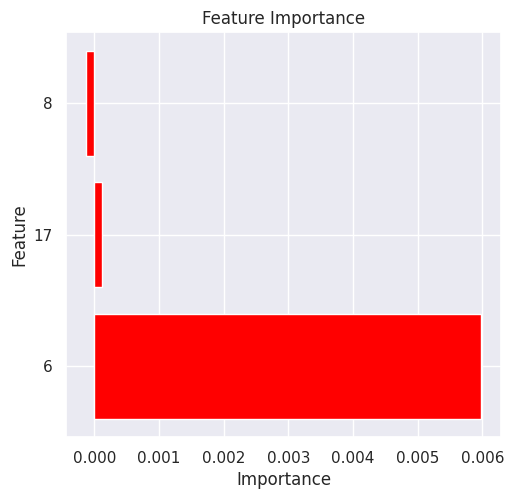

In [164]:
# ploting feature importance
importance = PLR.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize = (5, 5))
plt.title("Feature Importance", fontsize=14)

plt.barh(importance_df['Feature'], importance_df['Importance'], color='red')
plt.title("Feature Importance")
plt.xlabel('Importance')
plt.ylabel('Feature')

## Optimization

In [165]:
from sklearn.model_selection import GridSearchCV

grid ={
    'penalty': ['l1', 'l2'],  # Regularization type
    'C': [0.01, 0.1, 1, 10, 100]  # Regularization strength
}

PLR_optimized = LogisticRegression(solver='liblinear', max_iter=1000)

# Perform grid search with cross-validation
grid_search = GridSearchCV(PLR_optimized, grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Print the best parameters
print(f"Best parameters: {grid_search.best_params_}")

# Make predictions with the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Evaluate the best model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with best parameters: {accuracy:.2f}")

Best parameters: {'C': 0.01, 'penalty': 'l1'}
Accuracy with best parameters: 0.50


# Combined ROC Plot

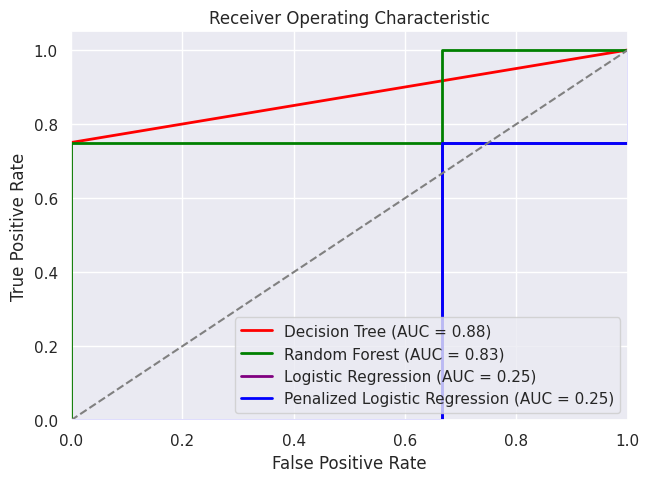

In [166]:
# Calculate the FPR and TPR for the Decision Tree model
probs_dt = dt_model.predict_proba(X_test)
preds_dt = probs_dt[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, preds_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Calculate the FPR and TPR for the Random Forest Classifier
probs_rf = rf_model.predict_proba(X_test)
preds_rf = probs_rf[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, preds_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calculate the FPR and TPR for the Logistic Regression model
probs_lr = LR.predict_proba(X_test)
preds_lr = probs_lr[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, preds_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Calculate the FPR and TPR for the Penalized Logistic Regression model
probs_plr = PLR.predict_proba(X_test)
preds_plr = probs_plr[:, 1]
fpr_plr, tpr_plr, _ = roc_curve(y_test, preds_plr)
roc_auc_plr = auc(fpr_plr, tpr_plr)

# Plotting the ROC curves
plt.figure()
plt.plot(fpr_dt, tpr_dt, color='red', lw=2, label='Decision Tree (AUC = %0.2f)' % roc_auc_dt)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
plt.plot(fpr_lr, tpr_lr, color='purple', lw=2, label='Logistic Regression (AUC = %0.2f)' % roc_auc_lr)
plt.plot(fpr_plr, tpr_plr, color='blue', lw=2, label='Penalized Logistic Regression (AUC = %0.2f)' % roc_auc_plr)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()